# Convergence Line identification

### Description

This example notebook demonstrates the more general identification of boundary layer convergence lines (CL) using the Instantaneous Contraction Rate (ICON) with hourly data from [BARRA-C2](https://doi.org/10.1071/ES25032).

The identification method is split into three modules:
1. **Loading model data and pre-processing**
2. **Computing ICON for CL diagnostics**
3. **Defining CL objects**

These steps will be outlined in this example notebook. ICON, as derived by [Cohen & Schultz (2005)](https://doi.org/10.1175/MWR2922.1), calculates the deformation and divergence of a wind field and is thus purely based on kinematics. It is here defined as:

$ICON = \frac{1}{2}(E-D)$

Where:

$D = \frac{\partial u}{\partial x} + \frac{\partial v}{\partial y}$, and:

$E = \sqrt{E_{st}^2+E_{sh}^2}$

With:

$E_{st} = \frac{\partial u}{\partial x} - \frac{\partial v}{\partial y}$, and:

$E_{sh} = \frac{\partial v}{\partial x} + \frac{\partial u}{\partial y}$

**Note** that there is no tracking of objects through time within the sea breeze code, this is not currently supported

### Data and software environment
This notebook requires direct access to the `ob53` [NCI project](https://my.nci.org.au/mancini/project/ob53/join) for BARRA-C2 data.

### References
Brown, A., Vincent, C. and Short, E. (2026). Identifying sea breezes from atmospheric model output (sea\_breeze v1.1). *Geoscientific Model Development, 19*(2), 933-953. https://doi.org/10.5194/gmd-19-933-2026

Cohen, R. A., & Schultz, D. M. (2005). Contraction Rate and Its Relationship to Frontogenesis, the Lyapunov Exponent, Fluid Trapping, and Airstream Boundaries. *Monthly Weather Review, 133*(5), 1353–1369. https://doi.org/10.1175/MWR2922.1

----

First load the required Python libraries

In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import xarray as xr
import pandas as pd
from dask.distributed import Client
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

Set and load the paths for your sea_breeze installation

In [2]:
sea_breeze_path = "/scratch/ng72/jd2435/cl_tracking/sea_breeze/"
sys.path.append(sea_breeze_path) # ⚠️ change to where your sea_breeze is placed

Set up your output path for sea breeze object statistics

In [3]:
stats_output_path = "/scratch/ng72/jd2435/cl_tracking/"

Set up a dask distributed client

In [22]:
client = Client()

Import the CL functions (embedded within the sea breeze package)

In [ ]:
import sea_breeze_filters
import sea_breeze_funcs
import load_model_data

## 1) Load model data
The first module of the convergence line code is to load and pre-process some model data. Here we are loading data from BARRA-C2 (https://dx.doi.org/10.25914/1x6g-2v48)

We first set the spatial and temporal bounds. In this example, we will be looking at an example of a cold front passing through Melbourne on November 21, 2016

In [26]:
#Time bounds for a single 6-hour case
t1 = "2016-11-21 05:00"
t2 = "2016-11-21 11:00"

#Lat lon and height bounds
lat_slice = slice(-42.0, -33.0)
lon_slice = slice(140.5, 150.5)

#Specify chunks for loading data:
chunks = {
    "time": 1,
    "lat": -1,
    "lon": -1
}

---

We can now load the required variables. ICON is typically calculated using the 0-500m average winds, however it is possible to use the wind field at only one elevation as well. In this example, we will use the 0-250m wind average, as BARRA does not include the 500m wind field.

In [27]:
#Load surface u and v winds, as well as surface specific humidity
uas = load_model_data.load_barra_variable(
    "uas",
    t1,
    t2,
    "AUST-04",
    "1hr",
    lat_slice,
    lon_slice,
    chunks=chunks,
    smooth=True
)

ua250m = load_model_data.load_barra_variable(
    "ua250m",
    t1,
    t2,
    "AUST-04",
    "1hr",
    lat_slice,
    lon_slice,
    chunks=chunks,
    smooth=True
)

vas = load_model_data.load_barra_variable(
    "vas",
    t1,
    t2,
    "AUST-04",
    "1hr",
    lat_slice,
    lon_slice,
    chunks=chunks,
    smooth=True
)

va250m = load_model_data.load_barra_variable(
    "va250m",
    t1,
    t2,
    "AUST-04",
    "1hr",
    lat_slice,
    lon_slice,
    chunks=chunks,
    smooth=True
)


/scratch/ng72/jd2435/cl_tracking/sea_breeze/load_model_data.py:387: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  da = xr.open_mfdataset(
/scratch/ng72/jd2435/cl_tracking/sea_breeze/load_model_data.py:387: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  da = xr.open_mfdataset(
/scratch/ng72/jd2435/cl_tracking/sea_breeze/load_model_data.py:387: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  da = xr.open_mfdataset(
/scratch/ng72/jd2435/cl_tracking/sea_breeze/load_model_data.py:387: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. Th

Calculate the average wind field over the chosen layer:

In [28]:
#Concatenate the two zonal wind fields into one DataArray:
ua_all = xr.concat(
    [uas, ua250m],
    dim="height"
)

#Calculate mean across the chosen layer:
ua_mean = ua_all.mean(dim="height")

#Concatenate the two meridional wind fields into one DataArray:
va_all = xr.concat(
    [vas, va250m],
    dim="height"
)

#Calculate mean across the chosen layer:
va_mean = va_all.mean(dim="height")

In [9]:
ua_mean = ua_mean.persist()
va_mean = va_mean.persist()

# 2) Compute ICON for CL diagnostics

We have now loaded all the necessary data, and are ready to calculate the instantaneous contraction rate. This function has been designed to read three inputs:

1. ua_mean: The mean zonal wind field over a layer (in this example the 0-250m zonal wind)
2. va_mean: The mean meridional wind field over a layer (in this example the 0-250m meridional wind)
3. filter_option: A boolean value of True or False. If this option is set to True, a filter will be applied to the ICON calculation at every hourly timestep where the mean field of the previous and the following timestep is subtracted. This is a useful filter to reduce noise and remove stationary CLs (i.e. mountain convergence), if wanted

In [10]:
#Calculate the instantaneous contraction rate
F = sea_breeze_funcs.icon(
        ua_mean,
        va_mean,
        filter_option=True
    ) 

We can look at the output:

In [11]:
F

<xarray.Dataset> Size: 6MB
Dimensions:     (time: 7, lon: 251, lat: 225)
Coordinates:
  * time        (time) datetime64[ns] 56B 2016-11-21T05:00:00 ... 2016-11-21T...
  * lon         (lon) float64 2kB 140.5 140.5 140.6 140.6 ... 150.4 150.5 150.5
  * lat         (lat) float64 2kB -41.97 -41.93 -41.89 ... -33.09 -33.05 -33.01
    crs         int32 4B 0
Data variables:
    F           (time, lat, lon) float64 3MB dask.array<chunksize=(1, 225, 251), meta=np.ndarray>
    F_filtered  (time, lat, lon) float64 3MB dask.array<chunksize=(1, 225, 251), meta=np.ndarray>

You may notice that the output here has two variables: F and F_filtered. F is the raw calculated ICON field, while F_filtered is the filtered field using the filter_option=True variable.

We can now plot to see the results:

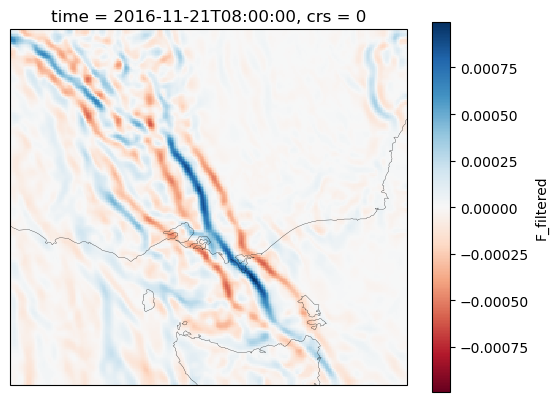

In [12]:
ax=plt.axes(projection=ccrs.PlateCarree())
F.sel(time=["2016-11-21 08:00"]).F_filtered.plot(cmap="RdBu")
ax.coastlines(lw=0.2)

We can also compare this with the unfiltered version:

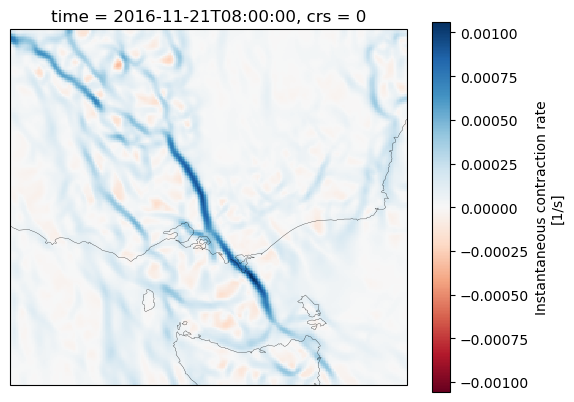

In [13]:
ax=plt.axes(projection=ccrs.PlateCarree())
F.sel(time=["2016-11-21 08:00"]).F.plot(cmap="RdBu")
ax.coastlines(lw=0.2)

In [14]:
F = F.persist()

## 3) Object detection and filtering

The third and final module is to use a threshold on each diagnostic, to define candidate convergence line objects, and then use filtering to remove objects that probably aren't sea breezes.

For the thresholds, we will use an aspect ratio of 3 and an area of minimum 300 pixels. We will also identify objects based on the 97th percentile. This threshold can be changed depending on the features you want to resolve.

There is also an option to filter out timesteps where no CL occurs in the previous or following timestep. This option is calles 'remove_single_timesteps', and in this example it will be set to True by default.

Note that there are several other options for filtering. Most of these are based on identifying seabreezes, and are thus not relevant or useful for identifying CLs more generally. This is due to the original purpose for this algorithm being mainly to identify seabreeze objects (see [Brown et al. (2026)](https://doi.org/10.5194/gmd-19-933-2026). To view all options included in the original code, they can be viewed under the Keyword section of the `filter_2d()` function documentation

In [15]:
#Set up filtering options. Here just use the aspect ratio and area filters
kwargs = {
    "orientation_filter":False,
    "aspect_filter":True,
    "area_filter":True,        
    "land_sea_temperature_filter":False,                    
    "temperature_change_filter":False,
    "humidity_change_filter":False,
    "wind_change_filter":False,
    "onshore_wind_filter":False,
    "dist_to_coast_filter":False,
    "output_land_sea_temperature_diff":False,        
    "time_filter":False,
    "area_thresh_pixels":300,
    "aspect_thresh":1,
    }

thresh_F = 0.0001

#Do the filtering using filter_3d
#Trigger the computation so that all the statistics are saved as a .csv file
F_objects = sea_breeze_filters.filter_3d(
    F.F_filtered,
    threshold="fixed",
    threshold_value=thresh_F,
    save_mask=False,
    filter_out_path=None,
    skipna=False,
    props_df_out_path=stats_output_path + "sb_stats_barra_r_F.csv",
    remove_single_timesteps=True,
    **kwargs).compute()

We can now have a look at the output. Note that this dataset also has two variables: the 'mask' variable containing every single output produced by the filter_3d function, as well as the 'objects_cleaned' variable containing all the objects except for those with no objects in the previous or following timesteps.

In [16]:
F_objects

<xarray.Dataset> Size: 795kB
Dimensions:          (time: 7, lon: 251, lat: 225)
Coordinates:
  * time             (time) datetime64[ns] 56B 2016-11-21T05:00:00 ... 2016-1...
  * lon              (lon) float64 2kB 140.5 140.5 140.6 ... 150.4 150.5 150.5
  * lat              (lat) float64 2kB -41.97 -41.93 -41.89 ... -33.05 -33.01
    crs              int32 4B 0
Data variables:
    mask             (time, lat, lon) bool 395kB False False ... False False
    objects_cleaned  (time, lat, lon) bool 395kB False False ... False False

We can also read the csv file. Note that this file will include all objects included in the 'mask' variable in our dataset:

In [17]:
a = pd.read_csv(stats_output_path + "sb_stats_barra_r_F.csv") #.set_index("time_utc")

In [18]:
a

,index,eccen,area,orient,major,minor,lon_centroid,lat_centroid,lst,aspect,area_km,time_utc
0,2,0.983015,453,-9.881893,82.196567,15.085131,143.02,-40.69,2016-11-21 17:32:04.800,5.448847,6792.984468,2016-11-21 08:00:00
1,7,0.991982,1858,-31.618838,231.422661,29.247127,145.98,-38.25,2016-11-21 17:43:55.200,7.912663,28853.810106,2016-11-21 08:00:00
2,15,0.956101,349,-72.928375,46.467395,13.616645,144.66,-39.73,2016-11-21 17:38:38.400,3.412544,5310.369295,2016-11-21 08:00:00
3,23,0.994765,479,-36.177853,94.965177,9.704247,143.18,-37.37,2016-11-21 17:32:43.200,9.785940,7528.975043,2016-11-21 08:00:00
4,43,0.994125,510,-48.534527,99.363976,10.754871,141.78,-34.09,2016-11-21 17:27:07.200,9.238975,8353.867844,2016-11-21 08:00:00
5,1,0.992829,768,-14.485960,114.860359,13.731229,141.42,-40.29,2016-11-21 15:25:40.800,8.364900,11590.223471,2016-11-21 06:00:00
6,5,0.991618,1265,-44.738427,163.483329,21.123302,145.26,-39.33,2016-11-21 15:41:02.400,7.739478,19347.867159,2016-11-21 06:00:00
7,31,0.986550,1306,-46.740384,162.701922,26.595015,142.98,-35.85,2016-11-21 15:31:55.200,6.117760,20938.212579,2016-11-21 06:00:00
8,54,0.975799,355,-11.672292,58.196137,12.725731,143.54,-34.41,2016-11-21 15:34:09.600,4.573108,5792.783691,2016-11-21 06:00:00
9,1,0.994769,324,-9.343145,73.138501,7.471138,142.26,-40.77,2016-11-21 16:29:02.400,9.789472,4855.108935,2016-11-21 07:00:00


One thing we can explore with this dataset is the evolution of CLs throughout a certain period:

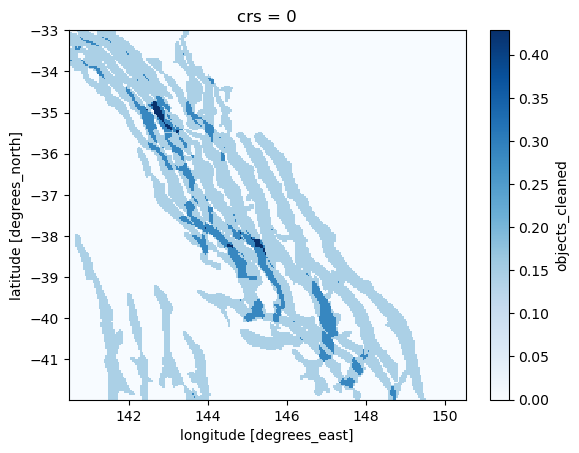

In [20]:
F_objects.sel(time=slice("2016-11-21 05:00", "2016-11-21 11:00"))['objects_cleaned'].mean(dim='time').plot(cmap="Blues")


We can also plot the individual objects at different times to compare and contrast:

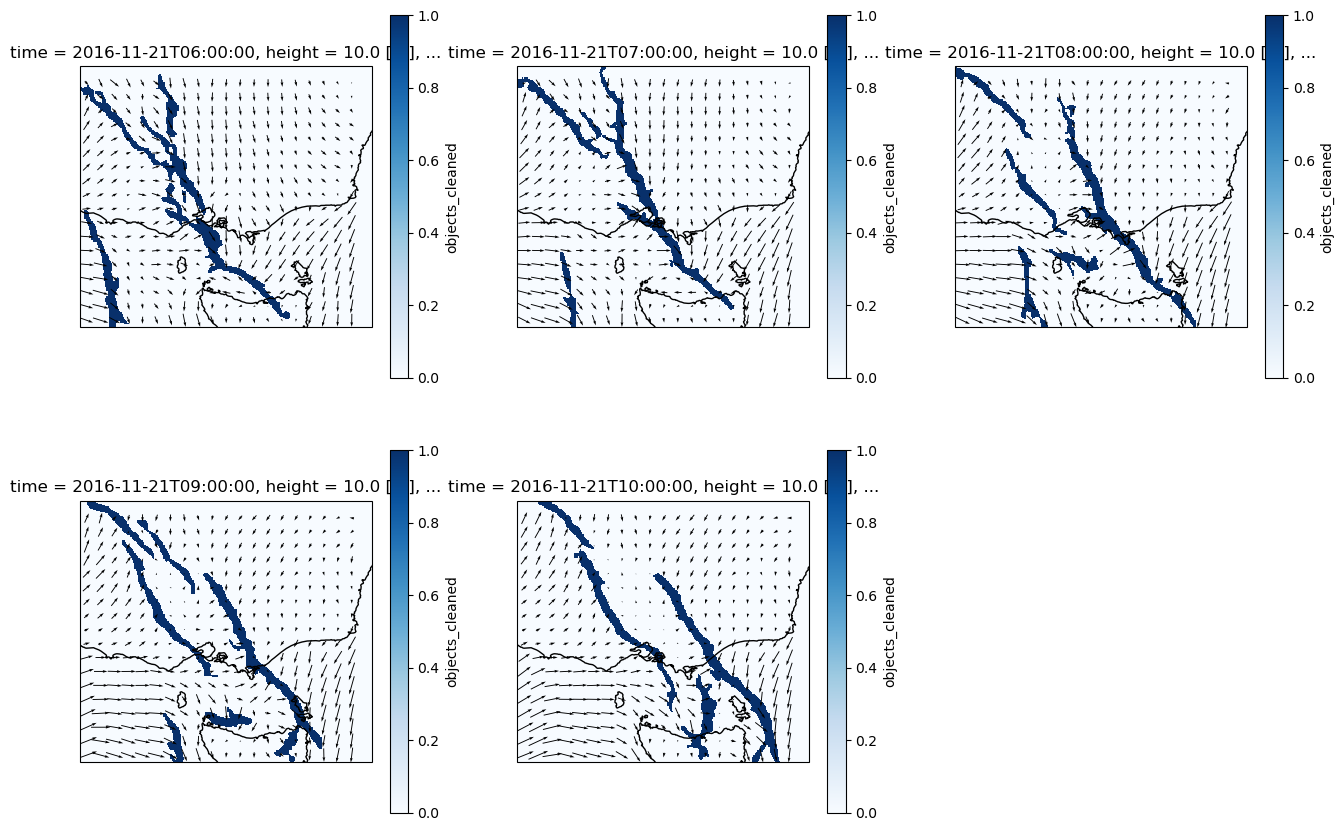

In [21]:
def plot(ds,field,ax,time,u,v,cmap):
    ds[field].sel(time=time).plot(cmap=cmap,vmin=0,vmax=1)
    xr.Dataset({"u":u,"v":v}).sel(time=t).coarsen({"lat":12,"lon":12},boundary="trim").mean().\
        plot.quiver(x="lon",y="lat",u="u",v="v")
    ax.coastlines()

plt.figure(figsize=[16,16])

t = "2016-11-21 06:00"
ax=plt.subplot(3,3,1,projection=ccrs.PlateCarree())
plot(F_objects,"objects_cleaned",ax,t,uas,vas,cmap="Blues")

t = "2016-11-21 07:00"
ax=plt.subplot(3,3,2,projection=ccrs.PlateCarree())
plot(F_objects,"objects_cleaned",ax,t,uas,vas,cmap="Blues")

t = "2016-11-21 08:00"
ax=plt.subplot(3,3,3,projection=ccrs.PlateCarree())
plot(F_objects,"objects_cleaned",ax,t,uas,vas,cmap="Blues")


t = "2016-11-21 09:00"
ax=plt.subplot(3,3,4,projection=ccrs.PlateCarree())
plot(F_objects,"objects_cleaned",ax,t,uas,vas,cmap="Blues")

t = "2016-11-21 10:00"
ax=plt.subplot(3,3,5,projection=ccrs.PlateCarree())
plot(F_objects,"objects_cleaned",ax,t,uas,vas,cmap="Blues")